# Notebook 01 — Ingesta y calidad

**Tesis:** Perfiles bancarios en Argentina — Entrega II (EDA)  
**Autora:** Victoria Di Liscia  

Este notebook carga las dos fuentes primarias del proyecto y las integra en un `dataset_master` a nivel banco:

1. **Scraper del BCRA** (`data/processed/bcra_bancos.db`) — estados contables, situación de deudores, información de estructura e indicadores económicos.
2. **Régimen de Transparencia Sección 36** (`data/raw/transparencia/*.CSV`) — oferta de productos (hipotecas, personales, prendarios, plazo fijo, paquetes, tarjetas, cajas de ahorro).

**Cortes temporales de interés:** Dic-2023, Dic-2024, Dic-2025 (corte transversal por período).

**Salidas de este notebook:**
- `data/processed/dataset_master_dic2023.csv`
- `data/processed/dataset_master_dic2024.csv`
- `data/processed/dataset_master_dic2025.csv`
- `data/processed/transparencia_agregada.csv`

## 1. Setup

In [1]:
import sqlite3
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
RAW_TRANSP = ROOT / "data" / "raw" / "transparencia"
PROCESSED = ROOT / "data" / "processed"
DB_PATH = PROCESSED / "bcra_bancos.db"

print(f"ROOT: {ROOT}")
print(f"SQLite existe: {DB_PATH.exists()}")
print(f"Transparencia: {sorted(p.name for p in RAW_TRANSP.glob('*.CSV'))}")

Matplotlib is building the font cache; this may take a moment.


ROOT: /Users/victoria/Documents/Maestria/tesis-perfiles-bancarios
SQLite existe: True
Transparencia: ['CAJADEAHORROS.CSV', 'HIPOTECA.CSV', 'PAQUETE.CSV', 'PERSONALES.CSV', 'PFIJO.CSV', 'PRENDARIOS.CSV', 'TARJETAS.CSV']


## 2. Carga del scraper (SQLite)

El scraper guarda todo en formato **long** (`codigo_bcra | nombre_banco | tipo_entidad | fuente | variable | periodo | valor`). Primero cargamos las 4 tablas, después pivoteamos por período.

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    ec = pd.read_sql("SELECT * FROM estados_contables", conn)
    sd = pd.read_sql("SELECT * FROM situacion_deudores", conn)
    es = pd.read_sql("SELECT * FROM informacion_estructura", conn)
    try:
        ie = pd.read_sql("SELECT * FROM indicadores_economicos", conn)
    except Exception as e:
        print(f"indicadores_economicos no disponible: {e}")
        ie = pd.DataFrame()

print(f"estados_contables:       {ec.shape}")
print(f"situacion_deudores:      {sd.shape}")
print(f"informacion_estructura:  {es.shape}")
print(f"indicadores_economicos:  {ie.shape}")

ec.head(3)

estados_contables:       (17345, 8)
situacion_deudores:      (7455, 8)
informacion_estructura:  (6633, 8)
indicadores_economicos:  (8680, 8)


,codigo_bcra,nombre_banco,tipo_entidad,fuente,variable,periodo,valor,scraping_fecha
0,00340,BACS BANCO DE CREDITO Y SECURITIZAC,privado_nacional,estados_contables,NaN,Dic-2023,NaN,2026-04-19
1,00340,BACS BANCO DE CREDITO Y SECURITIZAC,privado_nacional,estados_contables,A C T I V O,Dic-2023,148814589.0,2026-04-19
2,00340,BACS BANCO DE CREDITO Y SECURITIZAC,privado_nacional,estados_contables,EFECTIVO Y DEPOSITO EN BANCOS,Dic-2023,723106.0,2026-04-19


### 2.1 Períodos disponibles por fuente

Verificamos qué cortes temporales tenemos en cada tabla. El SPEC dice que:
- Estados contables: Dic-23, Dic-24, Nov-25, Dic-25, Ene-26
- Situación deudores: Dic-23, Dic-24, Oct-25, Nov-25, Dic-25
- Información estructura: Dic-23, Dic-24, Jun-25, Set-25, Dic-25

In [3]:
for nombre, df in [("estados_contables", ec), ("situacion_deudores", sd), ("informacion_estructura", es)]:
    periodos = sorted(df["periodo"].dropna().unique().tolist())
    print(f"{nombre:25s} | {len(periodos)} períodos: {periodos}")

estados_contables         | 5 períodos: ['Dic-2023', 'Dic-2024', 'Dic-2025', 'Ene-2026', 'Nov-2025']
situacion_deudores        | 5 períodos: ['Dic-2023', 'Dic-2024', 'Dic-2025', 'Ene-2026', 'Nov-2025']
informacion_estructura    | 12 períodos: ['Dic-2023', 'Dic-2024', 'Dic-2025', 'Ene-2026', 'Habilitadas', 'Jun-2025', 'Nov-2025', 'Of. de representación', 'Pendientes de habilitación', 'Set-2025', 'Sucursales', 'Total']


In [4]:
# Cobertura por banco × fuente (¿cuántos bancos tienen datos en cada fuente?)
resumen_cobertura = pd.DataFrame({
    "estados_contables":       [ec["codigo_bcra"].nunique()],
    "situacion_deudores":      [sd["codigo_bcra"].nunique()],
    "informacion_estructura":  [es["codigo_bcra"].nunique()],
    "indicadores_economicos":  [ie["codigo_bcra"].nunique() if not ie.empty else 0],
}, index=["bancos_distintos"])
resumen_cobertura

,estados_contables,situacion_deudores,informacion_estructura,indicadores_economicos
bancos_distintos,56,56,56,56


### 2.2 Pivotear long → wide por período

In [5]:
def pivotear(df: pd.DataFrame, periodo: str) -> pd.DataFrame:
    """Una fila por banco, una columna por variable, para un período dado."""
    sub = df[df["periodo"] == periodo]
    if sub.empty:
        return pd.DataFrame()
    wide = (sub
        .pivot_table(index=["codigo_bcra", "nombre_banco", "tipo_entidad"],
                     columns="variable", values="valor", aggfunc="first")
        .reset_index()
    )
    wide.columns.name = None
    return wide

# Cortes objetivo según SPEC
CORTES = ["Dic-2023", "Dic-2024", "Dic-2025"]

# Verificar que los nombres de los períodos coinciden con lo que devuelve el scraper.
# Si difieren (por ej. "31/12/2024" en vez de "Dic-2024"), imprimimos el mapeo.
cortes_reales = {}
for nombre, df in [("ec", ec), ("sd", sd), ("es", es)]:
    cortes_reales[nombre] = sorted(df["periodo"].dropna().unique().tolist())
cortes_reales

{'ec': ['Dic-2023', 'Dic-2024', 'Dic-2025', 'Ene-2026', 'Nov-2025'],
 'sd': ['Dic-2023', 'Dic-2024', 'Dic-2025', 'Ene-2026', 'Nov-2025'],
 'es': ['Dic-2023',
  'Dic-2024',
  'Dic-2025',
  'Ene-2026',
  'Habilitadas',
  'Jun-2025',
  'Nov-2025',
  'Of. de representación',
  'Pendientes de habilitación',
  'Set-2025',
  'Sucursales',
  'Total']}

In [6]:
# Generar snapshots pivoteados para los tres cortes
snapshots = {}
for corte in CORTES:
    snapshots[corte] = {
        "ec": pivotear(ec, corte),
        "sd": pivotear(sd, corte),
        "es": pivotear(es, corte),
    }
    print(f"\n── {corte} ──")
    for k, v in snapshots[corte].items():
        print(f"  {k}: {v.shape}")


── Dic-2023 ──
  ec: (56, 69)
  sd: (56, 33)
  es: (56, 18)

── Dic-2024 ──
  ec: (56, 69)
  sd: (56, 33)
  es: (56, 18)

── Dic-2025 ──
  ec: (56, 69)
  sd: (56, 33)
  es: (56, 18)


## 3. Carga del Régimen de Transparencia

In [7]:
def leer_transparencia(path: Path) -> pd.DataFrame:
    """Lee un archivo del Régimen Sección 36 con encoding latin-1 y separador ';'.

    - Renombra las columnas clave (código, nombre, fecha) para estandarizar el join.
    - Normaliza `codigo_entidad` a string de 5 dígitos con zfill.
    - Convierte columnas con decimales en coma a numéricas cuando >30% de los valores parsean.
    """
    df = pd.read_csv(path, sep=";", encoding="latin-1")
    df = df.rename(columns={
        df.columns[0]: "codigo_entidad",
        df.columns[1]: "nombre_entidad",
        df.columns[2]: "fecha_info",
    })
    df["codigo_entidad"] = df["codigo_entidad"].astype(str).str.zfill(5)
    for col in df.select_dtypes("object").columns:
        if col in ("codigo_entidad", "nombre_entidad"):
            continue
        convertida = df[col].str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
        numerica = pd.to_numeric(convertida, errors="coerce")
        if numerica.notna().sum() > len(df) * 0.3:
            df[col] = numerica
    return df

hipoteca   = leer_transparencia(RAW_TRANSP / "HIPOTECA.CSV")
personales = leer_transparencia(RAW_TRANSP / "PERSONALES.CSV")
prendarios = leer_transparencia(RAW_TRANSP / "PRENDARIOS.CSV")
pfijo      = leer_transparencia(RAW_TRANSP / "PFIJO.CSV")
paquete    = leer_transparencia(RAW_TRANSP / "PAQUETE.CSV")
tarjetas   = leer_transparencia(RAW_TRANSP / "TARJETAS.CSV")
cajas      = leer_transparencia(RAW_TRANSP / "CAJADEAHORROS.CSV")

for nombre, df in [("hipoteca", hipoteca), ("personales", personales), ("prendarios", prendarios),
                   ("pfijo", pfijo), ("paquete", paquete), ("tarjetas", tarjetas), ("cajas", cajas)]:
    print(f"{nombre:12s} {df.shape}  |  {df['codigo_entidad'].nunique()} entidades distintas")

hipoteca     (372, 22)  |  29 entidades distintas
personales   (2536, 21)  |  291 entidades distintas


prendarios   (570, 23)  |  47 entidades distintas
pfijo        (900, 12)  |  73 entidades distintas
paquete      (1087, 14)  |  33 entidades distintas
tarjetas     (545, 15)  |  139 entidades distintas
cajas        (61, 4)  |  61 entidades distintas


/var/folders/nt/6hzz6fjn7f75ky_hjs7gn1rc0000gn/T/ipykernel_21334/2657606398.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes("object").columns:
/var/folders/nt/6hzz6fjn7f75ky_hjs7gn1rc0000gn/T/ipykernel_21334/2657606398.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyd

### 3.1 Filtrar a los 56 bancos del scraper

Algunos archivos (especialmente `TARJETAS.CSV`) incluyen emisores no bancarios. Los filtramos antes de agregar.

In [8]:
BANCOS_SCRAPER = set(ec["codigo_bcra"].astype(str).str.zfill(5).unique())
print(f"Bancos del scraper: {len(BANCOS_SCRAPER)}")

def filtrar_bancos(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["codigo_entidad"].isin(BANCOS_SCRAPER)].copy()

hipoteca   = filtrar_bancos(hipoteca)
personales = filtrar_bancos(personales)
prendarios = filtrar_bancos(prendarios)
pfijo      = filtrar_bancos(pfijo)
paquete    = filtrar_bancos(paquete)
tarjetas   = filtrar_bancos(tarjetas)
cajas      = filtrar_bancos(cajas)

cobertura_transp = pd.DataFrame({
    "archivo": ["hipoteca", "personales", "prendarios", "pfijo", "paquete", "tarjetas", "cajas"],
    "filas":   [len(hipoteca), len(personales), len(prendarios), len(pfijo), len(paquete), len(tarjetas), len(cajas)],
    "bancos_con_oferta": [hipoteca["codigo_entidad"].nunique(), personales["codigo_entidad"].nunique(),
                          prendarios["codigo_entidad"].nunique(), pfijo["codigo_entidad"].nunique(),
                          paquete["codigo_entidad"].nunique(), tarjetas["codigo_entidad"].nunique(),
                          cajas["codigo_entidad"].nunique()],
})
cobertura_transp["% de 56 bancos"] = (cobertura_transp["bancos_con_oferta"] / len(BANCOS_SCRAPER) * 100).round(1)
cobertura_transp

Bancos del scraper: 56


,archivo,filas,bancos_con_oferta,% de 56 bancos
0,hipoteca,367,25,44.6
1,personales,536,43,76.8
2,prendarios,162,19,33.9
3,pfijo,630,50,89.3
4,paquete,873,28,50.0
5,tarjetas,352,41,73.2
6,cajas,46,46,82.1


### 3.2 Agregación por banco

Cada archivo tiene múltiples filas por banco (una por producto). Agregamos a nivel banco quedándonos con indicadores de oferta y mejores precios/tasas.

In [9]:
def _contiene_uva(serie: pd.Series) -> int:
    return int(serie.astype(str).str.upper().str.contains("UVA", na=False).any())

def _contiene_premium(serie: pd.Series) -> int:
    pat = "platinum|gold|black|signature|premium"
    return int(serie.astype(str).str.lower().str.contains(pat, na=False).any())

# HIPOTECA
hip_agg = (hipoteca.groupby("codigo_entidad").agg(
    hipoteca_uva=("Denominación", _contiene_uva),
    hipoteca_tea_max=("Tasa efectiva anual máxima", "min"),
    hipoteca_monto_max=("Monto máximo otorgable del préstamo", "max"),
    hipoteca_plazo_max=("Plazo máximo otorgable", "max"),
    hipoteca_n_productos=("Denominación", "count"),
).reset_index().assign(ofrece_hipoteca=1))

# PERSONALES
per_agg = (personales.groupby("codigo_entidad").agg(
    personal_tea_max=("Tasa efectiva anual máxima", "min"),
    personal_monto_max=("Monto máximo otorgable", "max"),
    personal_plazo_max=("Plazo máximo otorgable", "max"),
    personal_n_productos=("Denominación", "count"),
).reset_index().assign(ofrece_personal=1))

# PRENDARIOS
pren_agg = (prendarios.groupby("codigo_entidad").agg(
    prendario_tea_max=("Tasa efectiva anual máxima", "min"),
    prendario_monto_max=("Monto máximo otorgable", "max"),
    prendario_n_productos=("Denominación", "count"),
).reset_index().assign(ofrece_prendario=1))

# PFIJO
pf_agg = (pfijo.groupby("codigo_entidad").agg(
    pfijo_uva=("Denominación", _contiene_uva),
    pfijo_tea_min=("Tasa efectiva anual mínima", "max"),
    pfijo_monto_min=("Monto mínimo a invertir", "min"),
    pfijo_n_productos=("Denominación", "count"),
).reset_index().assign(ofrece_pfijo=1))

# PAQUETE
paq_agg = (paquete.groupby("codigo_entidad").agg(
    paquete_tiene_premium=("Segmento", _contiene_premium),
    paquete_comision_min=("Comisión máxima por servicio de mantenimiento de paquete", "min"),
    paquete_comision_max=("Comisión máxima por servicio de mantenimiento de paquete", "max"),
    paquete_n_productos=("Nombre completo del Paquete de Productos", "count"),
).reset_index().assign(ofrece_paquete=1))

# TARJETAS
tar_agg = (tarjetas.groupby("codigo_entidad").agg(
    tarjeta_tea_financiacion=("Tasa efectiva anual máxima de interés compensatorio por financiación de saldos", "min"),
    tarjeta_tea_adelanto=("Tasa efectiva anual máxima de interés por adelanto en efectivo", "min"),
    tarjeta_tiene_premium=("Segmento", _contiene_premium),
    tarjeta_comision_admin_min=("Comisión máxima por administración y mantenimiento de la cuenta", "min"),
    tarjeta_n_productos=("Nombre completo de la tarjeta de crédito", "count"),
).reset_index().assign(ofrece_tarjeta=1))

# CAJADEAHORROS — la única columna útil es un Sí/No
col_simpli = [c for c in cajas.columns if "simplificado" in c.lower()][0]
ca_agg = (cajas.groupby("codigo_entidad").agg(
    caja_apertura_simplificada=(col_simpli, lambda x: int(x.astype(str).str.upper().str.contains("SI", na=False).any())),
).reset_index())

for nombre, df in [("hip_agg", hip_agg), ("per_agg", per_agg), ("pren_agg", pren_agg),
                   ("pf_agg", pf_agg), ("paq_agg", paq_agg), ("tar_agg", tar_agg), ("ca_agg", ca_agg)]:
    print(f"{nombre:10s} {df.shape}")

hip_agg    (25, 7)
per_agg    (43, 6)
pren_agg   (19, 5)
pf_agg     (50, 6)
paq_agg    (28, 6)
tar_agg    (41, 7)
ca_agg     (46, 2)


In [10]:
# Join progresivo de todos los productos por codigo_entidad
dfs = [hip_agg, per_agg, pren_agg, pf_agg, paq_agg, tar_agg, ca_agg]
transparencia = reduce(lambda l, r: l.merge(r, on="codigo_entidad", how="outer"), dfs)

# Rellenar binarias (ausencia = banco no ofrece el producto)
cols_binarias = [c for c in transparencia.columns
                 if c.startswith("ofrece_") or c.endswith("_uva")
                    or c.endswith("_premium") or c.endswith("_simplificada")]
transparencia[cols_binarias] = transparencia[cols_binarias].fillna(0).astype(int)

# Contar cuántos productos ofrece cada banco
transparencia["n_productos_ofrecidos"] = transparencia[
    [c for c in transparencia.columns if c.startswith("ofrece_")]
].sum(axis=1)

print(f"transparencia agregada: {transparencia.shape}")
print(f"bancos cubiertos: {transparencia['codigo_entidad'].nunique()} / {len(BANCOS_SCRAPER)}")
transparencia.head()

transparencia agregada: (51, 34)
bancos cubiertos: 51 / 56


,codigo_entidad,hipoteca_uva,hipoteca_tea_max,hipoteca_monto_max,hipoteca_plazo_max,hipoteca_n_productos,ofrece_hipoteca,personal_tea_max,personal_monto_max,personal_plazo_max,personal_n_productos,ofrece_personal,prendario_tea_max,prendario_monto_max,prendario_n_productos,ofrece_prendario,pfijo_uva,pfijo_tea_min,pfijo_monto_min,pfijo_n_productos,ofrece_pfijo,paquete_tiene_premium,paquete_comision_min,paquete_comision_max,paquete_n_productos,ofrece_paquete,tarjeta_tea_financiacion,tarjeta_tea_adelanto,tarjeta_tiene_premium,tarjeta_comision_admin_min,tarjeta_n_productos,ofrece_tarjeta,caja_apertura_simplificada,n_productos_ofrecidos
0,00007,1,12.00,999999999.0,240.0,1.0,1,30.00,24800000.0,72.0,2.0,1,34.00,57000000.0,18.0,1,1,26.83,100.0,12.0,1,1,27000.0,70000.0,56.0,1,133.44,133.44,1,18500.00,12.0,1,1,6
1,00011,1,6.17,521192700.0,360.0,24.0,1,45.37,100000000.0,72.0,5.0,1,NaN,NaN,NaN,0,1,25.66,100.0,10.0,1,1,9427.0,75038.0,12.0,1,103.18,103.18,0,8801.54,1.0,1,1,5
2,00014,0,37.22,345689450.0,240.0,60.0,1,77.88,50000000.0,60.0,22.0,1,NaN,NaN,NaN,0,1,24.48,100.0,20.0,1,1,24700.0,85000.0,72.0,1,40.42,40.42,1,0.00,11.0,1,1,5
3,00015,1,9.27,300000000.0,240.0,2.0,1,147.19,145000000.0,96.0,8.0,1,67.97,130000000.0,7.0,1,1,23.89,1000.0,6.0,1,1,26000.0,76000.0,3.0,1,120.78,120.78,0,0.00,8.0,1,1,6
4,00017,1,7.76,999999999.0,360.0,13.0,1,249.85,70000000.0,72.0,7.0,1,28.00,55000000.0,4.0,1,1,22.54,1000.0,12.0,1,1,22900.0,78900.0,49.0,1,106.41,106.41,1,28900.00,8.0,1,1,6


In [11]:
PROCESSED.mkdir(parents=True, exist_ok=True)
transparencia.to_csv(PROCESSED / "transparencia_agregada.csv", index=False)
print(f"Guardado: {PROCESSED / 'transparencia_agregada.csv'}")

Guardado: /Users/victoria/Documents/Maestria/tesis-perfiles-bancarios/data/processed/transparencia_agregada.csv


## 4. Dataset master por corte temporal

Armamos un dataset integrado por cada corte (Dic-23, Dic-24, Dic-25):
estados contables + situación de deudores + estructura (del período) + transparencia (snapshot único).

In [12]:
def construir_master(ec_w: pd.DataFrame, sd_w: pd.DataFrame, es_w: pd.DataFrame,
                      transp: pd.DataFrame) -> pd.DataFrame:
    """Integra las tres fuentes del scraper con la transparencia agregada.

    Usa outer join entre fuentes del scraper para no perder bancos con datos parciales,
    y left join con transparencia (la ausencia en transparencia ya quedó codificada como 0).
    """
    frames = []
    for etiqueta, df in [("ec", ec_w), ("sd", sd_w), ("es", es_w)]:
        if df.empty:
            continue
        frames.append(df.rename(columns={"codigo_bcra": "codigo_entidad"}))

    if not frames:
        return pd.DataFrame()

    claves = ["codigo_entidad", "nombre_banco", "tipo_entidad"]
    scraper_combinado = reduce(lambda l, r: l.merge(r, on=claves, how="outer"), frames)

    # Normalizar codigo_entidad a string 5 dígitos para el join con transparencia
    scraper_combinado["codigo_entidad"] = scraper_combinado["codigo_entidad"].astype(str).str.zfill(5)
    master = scraper_combinado.merge(transp, on="codigo_entidad", how="left")

    # Los bancos del scraper ausentes en transparencia → ofrece_* = 0
    cols_bin = [c for c in master.columns if c.startswith("ofrece_") or c.endswith("_uva")
                or c.endswith("_premium") or c.endswith("_simplificada")]
    master[cols_bin] = master[cols_bin].fillna(0).astype(int)
    master["n_productos_ofrecidos"] = master["n_productos_ofrecidos"].fillna(0).astype(int)

    return master


datasets = {}
for corte in CORTES:
    snap = snapshots[corte]
    master = construir_master(snap["ec"], snap["sd"], snap["es"], transparencia)
    datasets[corte] = master
    fname = f"dataset_master_{corte.lower().replace('-', '')}.csv"
    master.to_csv(PROCESSED / fname, index=False)
    print(f"{corte}: {master.shape}  →  {fname}")

Dic-2023: (56, 147)  →  dataset_master_dic2023.csv
Dic-2024: (56, 147)  →  dataset_master_dic2024.csv
Dic-2025: (56, 147)  →  dataset_master_dic2025.csv


## 5. Calidad de datos

### 5.1 % de missings por variable y corte

In [13]:
def resumen_missings(df: pd.DataFrame, top: int = 20) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False) * 100
    return miss.round(2).head(top).to_frame("% missing")

for corte, df in datasets.items():
    print(f"\n── {corte}  (shape: {df.shape}) ──")
    print(f"Variables con 0% missing: {(df.isna().mean() == 0).sum()}")
    print(f"Variables con 100% missing: {(df.isna().mean() == 1).sum()}")
    print(resumen_missings(df, top=10))


── Dic-2023  (shape: (56, 147)) ──
Variables con 0% missing: 39
Variables con 100% missing: 0
                                  % missing
FILIALES EN EL EXTERIOR               96.43
DETERIORO DE VALOR                    96.43
OBLIGACIONES SUBORDINADAS             91.07
EN ENTIDADES FINANCIERAS              87.50
prendario_n_productos                 66.07
prendario_monto_max                   66.07
prendario_tea_max                     66.07
OTRO RESULTADO INTEGRAL               64.29
DE ACTIVIDAD FIDUCIARIA DEUDORAS      62.50
COBROS NO APLICADOS                   60.71

── Dic-2024  (shape: (56, 147)) ──
Variables con 0% missing: 39
Variables con 100% missing: 0
                                  % missing
FILIALES EN EL EXTERIOR               96.43
DETERIORO DE VALOR                    94.64
OBLIGACIONES SUBORDINADAS             91.07
EN ENTIDADES FINANCIERAS              87.50
prendario_n_productos                 66.07
prendario_monto_max                   66.07
prendario_tea_max 

### 5.2 Mapa de missings (missingno)


── Mapa de missings — Dic-2023 ──


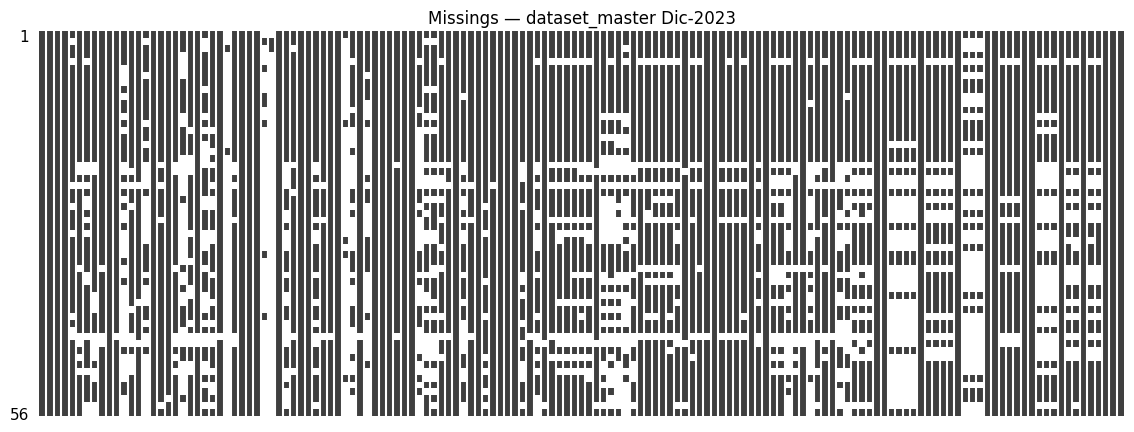


── Mapa de missings — Dic-2024 ──


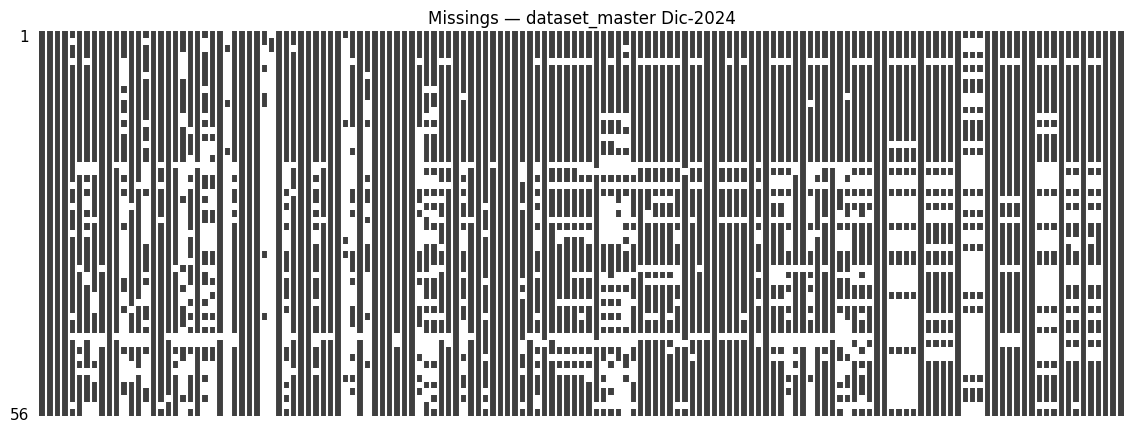


── Mapa de missings — Dic-2025 ──


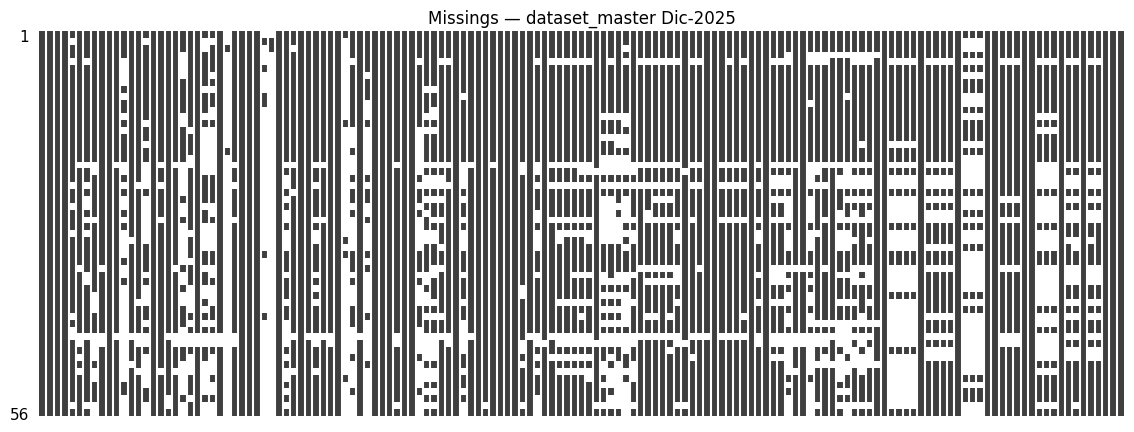

In [14]:
for corte, df in datasets.items():
    print(f"\n── Mapa de missings — {corte} ──")
    msno.matrix(df, figsize=(14, 5), sparkline=False, fontsize=9)
    plt.title(f"Missings — dataset_master {corte}")
    plt.show()

### 5.3 Cobertura por banco × corte

¿Qué bancos tienen datos en cada uno de los tres cortes?

In [15]:
cobertura = pd.DataFrame(index=sorted(BANCOS_SCRAPER))
for corte, df in datasets.items():
    codigos_presentes = set(df["codigo_entidad"].astype(str).str.zfill(5))
    cobertura[corte] = cobertura.index.map(lambda c: int(c in codigos_presentes))
cobertura["presente_en"] = cobertura.sum(axis=1)

# Adjuntar nombre y tipo
meta = ec[["codigo_bcra", "nombre_banco", "tipo_entidad"]].drop_duplicates().set_index("codigo_bcra")
cobertura = cobertura.join(meta)

print("Bancos por nº de cortes en los que aparecen:")
print(cobertura["presente_en"].value_counts().sort_index().to_frame("n_bancos"))

print("\nBancos que NO aparecen en los 3 cortes:")
cobertura[cobertura["presente_en"] < 3]

Bancos por nº de cortes en los que aparecen:
             n_bancos
presente_en          
3                  56

Bancos que NO aparecen en los 3 cortes:


,Dic-2023,Dic-2024,Dic-2025,presente_en,nombre_banco,tipo_entidad


### 5.4 Bancos del scraper ausentes en transparencia

La ausencia es información: un banco sin reporte de transparencia probablemente no ofrece productos minoristas estandarizados.

In [16]:
codigos_transp = set(transparencia["codigo_entidad"])
faltantes_transp = BANCOS_SCRAPER - codigos_transp
print(f"Bancos del scraper ausentes en transparencia: {len(faltantes_transp)}")

if faltantes_transp:
    ausentes = meta.loc[sorted(faltantes_transp)]
    print(ausentes)

Bancos del scraper ausentes en transparencia: 5
                                    nombre_banco      tipo_entidad
codigo_bcra                                                       
00016                              CITIBANK N.A.        extranjero
00198                      BANCO DE VALORES S.A.  privado_nacional
00266                                BNP PARIBAS        extranjero
00300        BANCO DE INVERSION Y COMERCIO EXTER           publico
00331               BANCO CETELEM ARGENTINA S.A.        extranjero


### 5.5 Tipos de datos

Las variables del scraper son numéricas (`valor` se parseó en el scraper). Las de transparencia deberían serlo también luego de `leer_transparencia`. Chequeamos.

In [17]:
corte_ref = "Dic-2024"
dtype_counts = datasets[corte_ref].dtypes.value_counts().to_frame("n_columnas")
print(dtype_counts)

cols_object = datasets[corte_ref].select_dtypes("object").columns.tolist()
print(f"\nColumnas tipo object ({len(cols_object)}):")
print(cols_object)

         n_columnas
float64         132
int64            12
str               3

Columnas tipo object (3):
['codigo_entidad', 'nombre_banco', 'tipo_entidad']


/var/folders/nt/6hzz6fjn7f75ky_hjs7gn1rc0000gn/T/ipykernel_21334/545529153.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_object = datasets[corte_ref].select_dtypes("object").columns.tolist()


### 5.6 Outliers: detección univariada (no eliminar)

Para variables clave, marcamos qué bancos están fuera del rango IQR ± 1.5×IQR. Solo documentamos.

In [18]:
def outliers_iqr(serie: pd.Series) -> pd.Series:
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

df_ref = datasets[corte_ref]
candidatas = [c for c in ["ACTIVO", "PATRIMONIO NETO", "hipoteca_tea_max", "personal_tea_max",
                           "pfijo_tea_min", "tarjeta_tea_financiacion", "paquete_comision_max"]
              if c in df_ref.columns]

resumen_out = []
for col in candidatas:
    serie = pd.to_numeric(df_ref[col], errors="coerce")
    mask = outliers_iqr(serie.dropna())
    resumen_out.append({
        "variable": col,
        "n_validos": serie.notna().sum(),
        "n_outliers": int(mask.sum()),
        "min": serie.min(),
        "p50": serie.median(),
        "max": serie.max(),
    })
pd.DataFrame(resumen_out)

,variable,n_validos,n_outliers,min,p50,max
0,hipoteca_tea_max,25,1,3.56,12.00,37.22
1,personal_tea_max,43,6,9.38,118.00,952.11
2,pfijo_tea_min,50,3,14.94,24.39,39.16
3,tarjeta_tea_financiacion,40,6,0.00,127.01,461.06
4,paquete_comision_max,28,1,1787.17,57867.29,345674.31


### 5.7 Coherencia de códigos de entidad entre fuentes

Verificamos que el join scraper ↔ transparencia identifica correctamente al mismo banco en ambos lados.

In [19]:
# Tomar un puñado de códigos presentes en ambas fuentes y comparar los nombres
codigos_comunes = sorted(BANCOS_SCRAPER & codigos_transp)[:15]
nombres_scraper = meta.loc[[c for c in codigos_comunes if c in meta.index], "nombre_banco"]
nombres_transp = (transparencia.set_index("codigo_entidad")
                  .loc[codigos_comunes]
                  .reset_index()
                  .drop_duplicates("codigo_entidad")
                  .set_index("codigo_entidad")["nombre_entidad"]
                  if "nombre_entidad" in transparencia.columns else pd.Series(dtype=str))

# Los nombres en transparencia vienen por archivo; los re-extraemos desde un archivo fuente
nombres_transp_raw = (pd.concat([hipoteca, personales, pfijo, tarjetas], ignore_index=True)
                         [["codigo_entidad", "nombre_entidad"]]
                         .drop_duplicates("codigo_entidad")
                         .set_index("codigo_entidad")["nombre_entidad"])

comparacion = pd.DataFrame({
    "scraper": nombres_scraper,
    "transparencia": nombres_transp_raw.reindex(nombres_scraper.index),
})
comparacion

,scraper,transparencia
codigo_bcra,,
00007,BANCO DE GALICIA Y BUENOS AIRES S.A,BANCO DE GALICIA Y BUENOS AIRES S.A.
00011,BANCO DE LA NACION ARGENTINA,BANCO DE LA NACION ARGENTINA
00014,BANCO DE LA PROVINCIA DE BUENOS AIR,BANCO DE LA PROVINCIA DE BUENOS AIRES
00015,INDUSTRIAL AND COMMERCIAL BANK OF C,INDUSTRIAL AND COMMERCIAL BANK OF CHINA (ARGEN...
00017,BANCO BBVA ARGENTINA S.A.,BANCO BBVA ARGENTINA S.A.
00020,BANCO DE LA PROVINCIA DE CORDOBA S.,BANCO DE LA PROVINCIA DE CORDOBA S.A.
00027,BANCO SUPERVIELLE S.A.,BANCO SUPERVIELLE S.A.
00029,BANCO DE LA CIUDAD DE BUENOS AIRES,BANCO DE LA CIUDAD DE BUENOS AIRES
00034,BANCO PATAGONIA S.A.,BANCO PATAGONIA S.A.


## 6. Resumen del dataset final

Elegimos Dic-2024 como corte de referencia para el clustering (completitud máxima y cierre de ejercicio).

In [20]:
df_ref = datasets["Dic-2024"]
print(f"Dataset master Dic-2024: {df_ref.shape}")
print(f"\nDistribución por tipo de entidad:")
print(df_ref["tipo_entidad"].value_counts(dropna=False))

print(f"\nOferta de productos:")
ofertas = [c for c in df_ref.columns if c.startswith("ofrece_")]
print(df_ref[ofertas].sum().sort_values(ascending=False).to_frame("bancos_que_ofrecen"))

Dataset master Dic-2024: (56, 147)

Distribución por tipo de entidad:
tipo_entidad
privado_nacional    30
publico             17
extranjero           9
Name: count, dtype: int64

Oferta de productos:
                  bancos_que_ofrecen
ofrece_pfijo                      50
ofrece_personal                   43
ofrece_tarjeta                    41
ofrece_paquete                    28
ofrece_hipoteca                   25
ofrece_prendario                  19


## 7. Artefactos generados

- `data/processed/transparencia_agregada.csv` — una fila por banco con oferta de productos.
- `data/processed/dataset_master_dic2023.csv`
- `data/processed/dataset_master_dic2024.csv`
- `data/processed/dataset_master_dic2025.csv`

El notebook 02 usa estos archivos para el EDA principal (distribuciones, correlaciones, comparativas por tipo de banco).